**GROUP 02**

**DATASET** - IBM HR ANALYTICS EMPLOYEE ATTRITION.

**DEPTH TRACK** - CLUSTERING DEPTH

**TEAM MEMBER NAMES:**

1)ESSANGENYI BRIGHT VICTOR

2)DANIEL OFUKOWOICHO ODEH

3)UWEH BLESSING

4)SUNDAY GLORIA AUDU

5)RACHEL OLUWATOBILOBA ODEJOBI

6)ADEYEMO OREOLUWA VICTORIA

7)KEHINDE KANYINSOLA TAIWO

8)UBONG KINGSLEY UFOT

9)OGUNSOLA IYABO NGOZI

10)AMUSA QUDUS KEHINDE

PART 1 - DATA FOUNDATION

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, mean_absolute_error, r2_score, classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
!pip install kagglehub imbalanced-learn --quiet

In [ ]:
import kagglehub

path = kagglehub.dataset_download('pavansubhasht/ibm-hr-analytics-attrition-dataset')
print('Dataset path:', path)

import os
files = os.listdir(path)
print('Files in dataset:', files)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Dataset path: /kaggle/input/ibm-hr-analytics-attrition-dataset
Files in dataset: ['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [ ]:
df = pd.read_csv(f'{path}/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
conn = sqlite3.connect("data.db")
df.to_sql("hr_attrition", conn, if_exists="replace", index=False)

1470

In [ ]:
pd.read_sql_query(
    """
    SELECT EducationField, AVG(MonthlyIncome) AS AvgMonthlyIncome
    FROM hr_attrition
    GROUP BY EducationField
    Having AVG(MonthlyIncome) > 5000
    ORDER BY AvgMonthlyIncome DESC;
    """,
    conn
)

,EducationField,AvgMonthlyIncome
0,Marketing,7348.584906
1,Human Resources,7241.148148
2,Medical,6510.036638
3,Life Sciences,6463.288779
4,Other,6071.548780
5,Technical Degree,5758.303030


From the above SQL query, the Education Field with the highest Average Monthly Salary greater than 10,000 is Marketing followed by Human Resources, then Medical, followed by Life Sciences, then Other with the least being Technical Degree.

In [ ]:
pd.read_sql_query("""
    SELECT
        Attrition,
        ROUND(AVG(MonthlyIncome), 2)     AS avg_monthly_income,
        ROUND(AVG(YearsAtCompany), 2)    AS avg_years_at_company,
        ROUND(AVG(Age), 2)               AS avg_age,
        COUNT(*)                          AS headcount
    FROM hr_attrition
    GROUP BY Attrition
""", conn)

,Attrition,avg_monthly_income,avg_years_at_company,avg_age,headcount
0,No,6832.74,7.37,37.56,1233
1,Yes,4787.09,5.13,33.61,237


This query tells us how people attrited based on their monthly salary, average years at the company, age and it calculates the number of employees that left and those that stayed.

In [ ]:
pd.read_sql_query(
    """
    SELECT JobRole, AVG(YearsSinceLastPromotion) AS AvgYearsSincePromotion
    FROM hr_attrition
    GROUP BY JobRole
    ORDER BY AvgYearsSincePromotion DESC
    LIMIT 5;
    """,
    conn
)

,JobRole,AvgYearsSincePromotion
0,Manager,4.833333
1,Research Director,3.187500
2,Healthcare Representative,2.969466
3,Sales Executive,2.484663
4,Manufacturing Director,2.117241


From the above SQL query, we can determine the roles that are waiting longest for promotion on an average. Based on the query above, the longest waiting is the Manager, followed by Research Director with the least being Manufacturing Director. Some of these roles that have the longest years is because they are already at top roles.

In [ ]:
df.shape

(1470, 35)

In [ ]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [ ]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


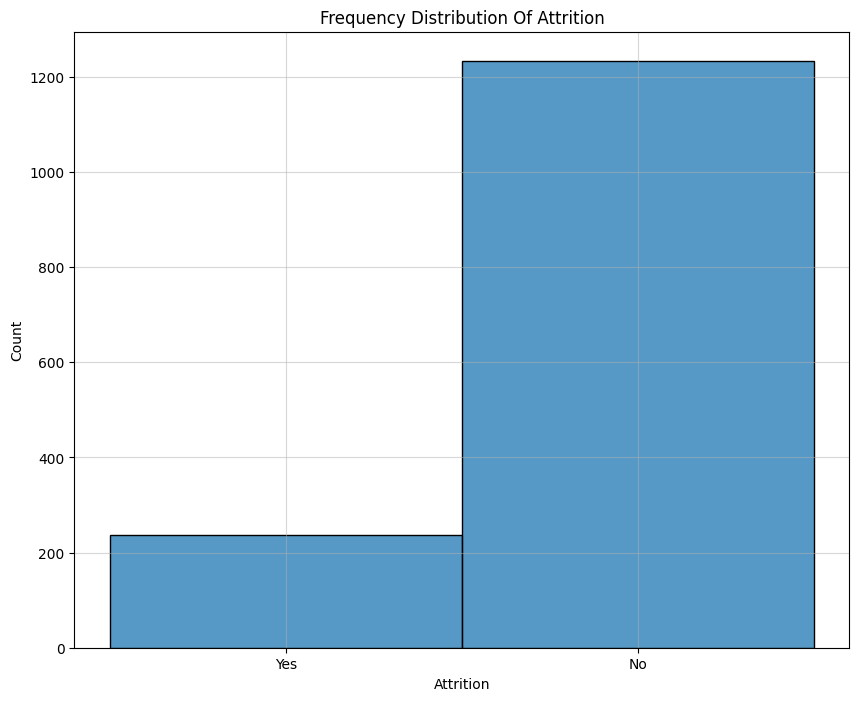

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df["Attrition"])
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.title("Frequency Distribution Of Attrition")
plt.grid(True, alpha=0.5)
plt.show()

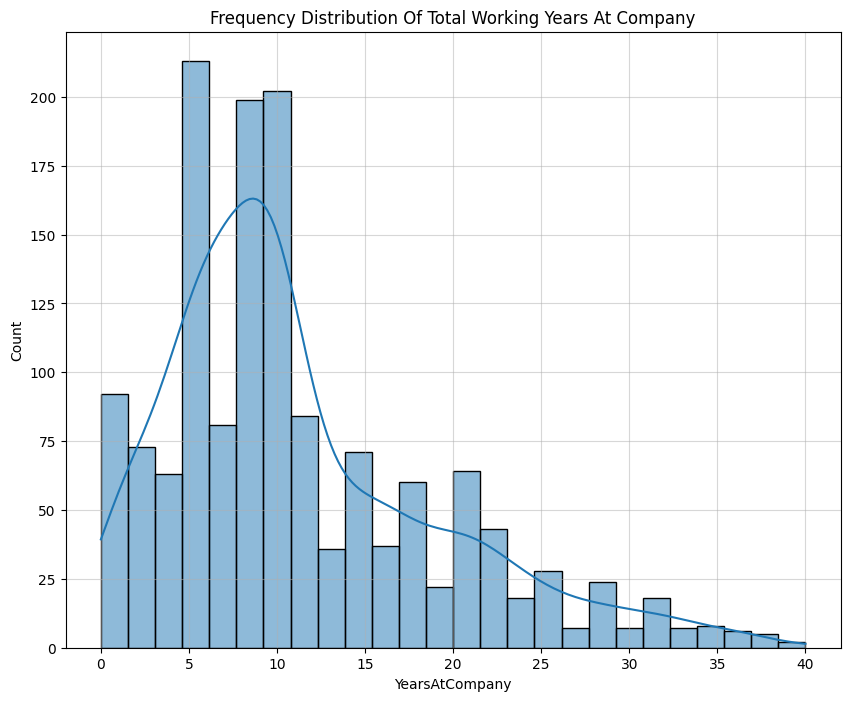

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df["TotalWorkingYears"], kde=True)
plt.xlabel("YearsAtCompany")
plt.ylabel("Count")
plt.title("Frequency Distribution Of Total Working Years At Company")
plt.grid(True, alpha=0.5)
plt.show()

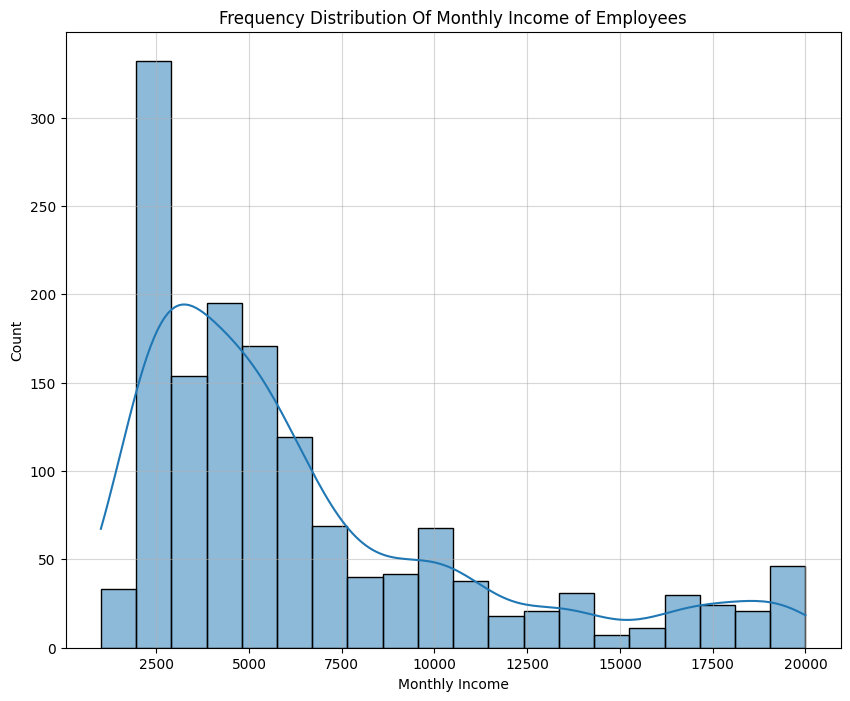

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(df["MonthlyIncome"], kde=True)
plt.xlabel("Monthly Income")
plt.ylabel("Count")
plt.title("Frequency Distribution Of Monthly Income of Employees")
plt.grid(True, alpha=0.5)
plt.show()

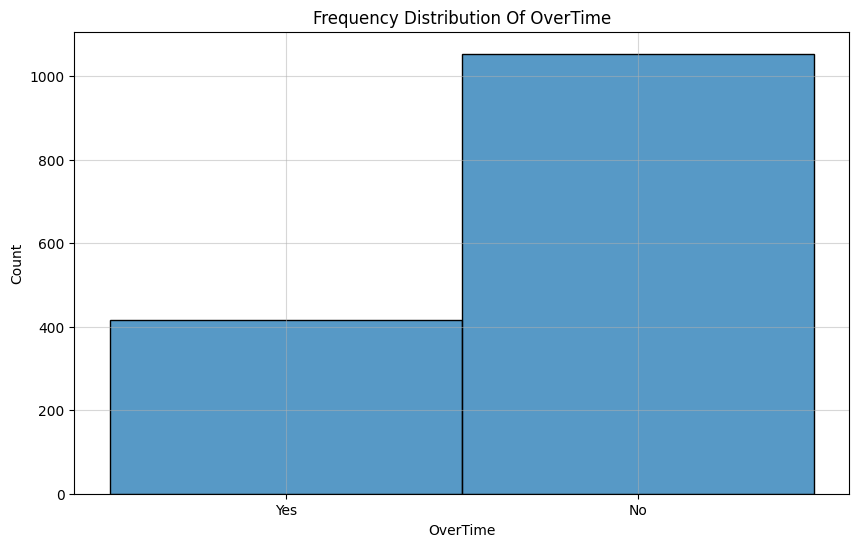

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df["OverTime"])
plt.xlabel("OverTime")
plt.ylabel("Count")
plt.title("Frequency Distribution Of OverTime")
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
df["NumCompaniesWorked"].replace(0, df["NumCompaniesWorked"].median())

,NumCompaniesWorked
0,8
1,1
2,6
3,1
4,9
...,...
1465,4
1466,4
1467,1
1468,2


I replaced the missing zeros in NumOfCompaniesWorked column with median because after investigating the zeros value I found out some abnormal patterns like an employee who is 38 and with Job Level 3 having never worked at any company is not realistic.

Also, I checked other colums concerning the zeros and it was justified.

In [ ]:
df=df.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1)

I dropped the above columns due to the following reasons. I dropped Employee Count, Over18 and StandardHours because it had a constant value and it would not add anything meaningful to our prediction. I also dropped EmployeeNumber column because it is just like an employee ID and it is not useful for our predictions too.


FEATURE ENGINEERING AND ENCODING

In [ ]:
df["IncomePerExperienceYear"] = df["MonthlyIncome"] / (df["TotalWorkingYears"] + 1)

I created another feature called Income Per Experience Year where I employed the ratio year. It calculates the monthly Income of an employee in relation to the Total Working Years. The +1 added is for employees with zero total working years so as to prevent error in the calculation. It measures if experienced workers are being paid properly.

In [ ]:
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)

This new feature engineered represents or calculates the years spent at a company with in relation to the total working years.

In [ ]:
df["WorkingExperience"] = pd.cut(df["TotalWorkingYears"], bins=[0,3,7,15,40], labels=["L1_Entry", "L2_Mid", "L3_Experienced", "L4_Veteran"], include_lowest=True)

I created a new feature for my dataset called Working Experience where I employed the Binning method. It groups the Total Working Years into four categories and assigns them to their respective labels.
0-3 = Entry Level,
3-7 = Mid Level,
7-15 = Experienced,
15-40 = Veteran.

In [ ]:
df["MonthlyIncome_per_JobLevel"] = df["MonthlyIncome"] / df["JobLevel"]

I created another feature where I combined two columns to an interaction column. It reveals compensation fairness relative to each employee's Job Level.

In [ ]:
le = LabelEncoder()
df["WorkingExperience"] = le.fit_transform(df["WorkingExperience"])

I used Label Encoder for my Working Experience column. This is beause it encodes based on rank when something is greater than the order and Working Experience had attributes that was needed to be ranked.

In [ ]:
columns_to_encode = ["Attrition", "BusinessTravel", "Department", "EducationField", "Gender", "JobRole", "MaritalStatus", "OverTime"]

I used One Hot Encoder for the remaining categorical columns. This is because firstly I need to convert them to numbers and because the attributes I have in the other columns do not need to be ranked.

In [ ]:
df_onehot=pd.get_dummies(df[columns_to_encode], drop_first=True)

In [ ]:
df = df.drop(df[columns_to_encode], axis=1)

In [ ]:
df = pd.concat([df.reset_index(drop=True), df_onehot.reset_index(drop=True)], axis=1)

I dropped the initial columns because the were categorical and I just encoded them. So I concatenated the encoded columns together with the numerical features so as to have them all numerical.

In [ ]:
X = df.drop(["Attrition_Yes"], axis=1).astype(float)
Y = df["Attrition_Yes"].astype(float)

In [ ]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

I used Standard scaler because the mean and standard deviation were far from each other and I wanted each column to have a mean 0 and standard deviation 1.

PART 3 - CLUSTERING ANALYSIS

In [ ]:
#Elbow Method
inertias = []
k_range = range(2,10)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  kmeans.fit(X_scaled)
  inertias.append(kmeans.inertia_)
  print(f"K = {k}: Inertia = {kmeans.inertia_:.2f}")

K = 2: Inertia = 64466.35
K = 3: Inertia = 60092.18
K = 4: Inertia = 58017.46
K = 5: Inertia = 55966.89
K = 6: Inertia = 54605.59
K = 7: Inertia = 53257.68
K = 8: Inertia = 51413.45
K = 9: Inertia = 49903.97


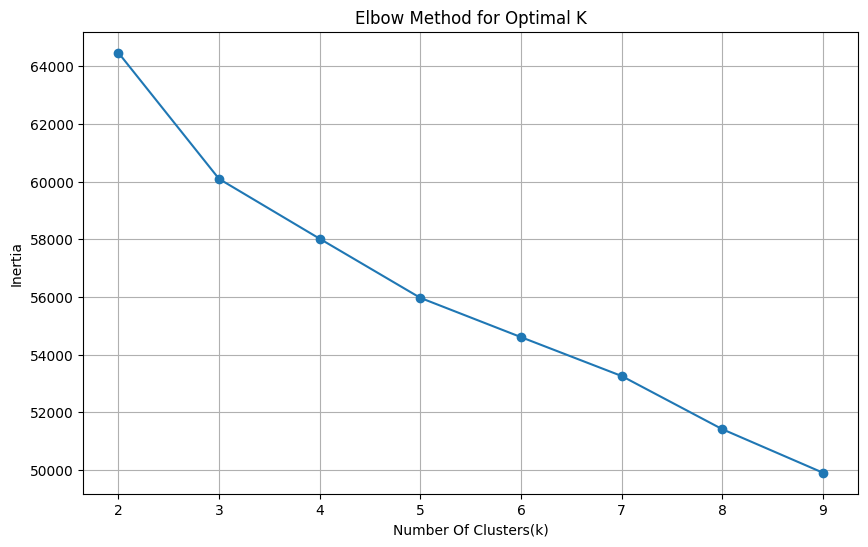

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_range, inertias, marker="o", linestyle="-")
plt.xlabel("Number Of Clusters(k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.grid(True)
plt.show()

In [ ]:
#Silhouette score
from sklearn.metrics import silhouette_score
silhouette_scores = []
k_range = range(2,11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
  cluster_labels = kmeans.fit_predict(X_scaled)

  silhouette_avg = silhouette_score(X_scaled, cluster_labels)
  silhouette_scores.append(silhouette_avg)
  print(f"K = {k} : Silhouette Score = {silhouette_avg}")

K = 2 : Silhouette Score = 0.11889239802782789
K = 3 : Silhouette Score = 0.09137899129507308
K = 4 : Silhouette Score = 0.09783015669669227
K = 5 : Silhouette Score = 0.08598774579357894
K = 6 : Silhouette Score = 0.0864768435676866
K = 7 : Silhouette Score = 0.08360378250083043
K = 8 : Silhouette Score = 0.10023922296931732
K = 9 : Silhouette Score = 0.10221698344423713
K = 10 : Silhouette Score = 0.09272466829185427


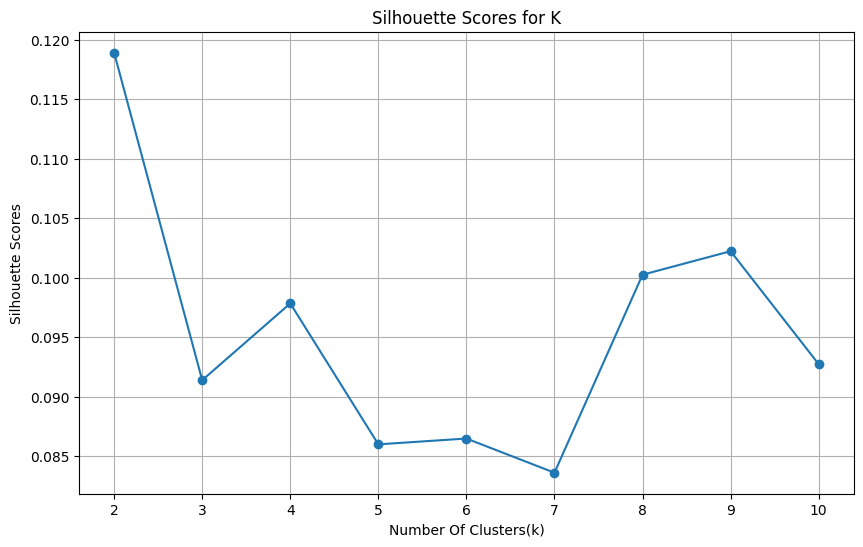

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(k_range, silhouette_scores, marker="o", linestyle="-")
plt.xlabel("Number Of Clusters(k)")
plt.ylabel("Silhouette Scores")
plt.title("Silhouette Scores for K")
plt.grid(True)
plt.show()

In [ ]:
# Building final KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

I picked my K value to be 4 based on the elbow method. Although the silhouette score suggested 2, I chose 4 becauseit provides more granular and actionable employee personas that are more useful for HR decision making. The elbow method also supported K=4 as the point of maximum curvature.

In [ ]:
df["kmeans_clusters"] = kmeans_labels
df["kmeans_clusters"].value_counts()

,count
kmeans_clusters,
3,762
1,319
0,256
2,133


In [ ]:
df.groupby("kmeans_clusters").agg({
    "MonthlyIncome" : "mean",
    "IncomePerExperienceYear" : "mean",
    "YearsWithCurrManager" : "mean",
    "YearsSinceLastPromotion" : "mean",
    "Age" : "mean",
    "JobLevel" : "mean",
    "NumCompaniesWorked" : "mean",
    "MonthlyIncome_per_JobLevel" : "mean",
    "OverTime_Yes" : "mean"
}).round(2)


,MonthlyIncome,IncomePerExperienceYear,YearsWithCurrManager,YearsSinceLastPromotion,Age,JobLevel,NumCompaniesWorked,MonthlyIncome_per_JobLevel,OverTime_Yes
kmeans_clusters,,,,,,,,,
0,14968.15,658.64,6.43,4.54,46.06,3.89,3.38,3830.24,0.30
1,6781.26,640.46,4.56,2.35,36.63,2.29,2.69,2942.88,0.29
2,3135.41,641.72,2.23,1.08,32.09,1.21,2.09,2577.22,0.28
3,4130.22,532.11,3.50,1.52,34.82,1.50,2.57,2768.24,0.28


Cluster 0 represents Tenured High Level Professionals. Employees in this category are the oldest among the clusters with the most paid average monthly income of $14968.15. They have the most years spent with their current manager, highest Job Level coupled with Income per Experience Year. They spent reasonable time working Over time. They are second to the last contributors to the different clusters.

Cluster 1 represents the Balanced Career Progressors. The employees here have a very decent monthly income of about $6781.26 on average which is the second highest. They are middle aged with a good number of working years with their current manager. Coupled with the fact that their Job Level is decent, they work little or medium overtime.

Cluster 2 represents the Low Income Early Career Drifters. The employees here are the youngest with the lowest Monthly Income and Job Level. Although their Years since last promotion, Income per experience year and Over time are very okay. They tend to leave the company more.

Cluster 3 represents the Experienced but Undervalued Staff. Employees here are middle aged but they are not compensated well enough with the second to the least Monthly salary. Their Job Level is low but the years with their current manager and years since last promotion is really good, meaning they are undervalued.

In [ ]:
# Map cluster numbers to your persona names
persona_names = {
    0: 'Tenured High Level Professionals',
    1: 'Balanced Career Progressors',
    2: 'Low Income Early Career Drifters',
    3: 'Experienced but Undervalued Staff'
}

df['Persona'] = df['kmeans_clusters'].map(persona_names)

# Define features used for profiling
profile_cols = ['MonthlyIncome', 'IncomePerExperienceYear', 'YearsWithCurrManager',
                'YearsSinceLastPromotion', 'Age', 'JobLevel', 'JobSatisfaction',
                'JobInvolvement', 'OverTime_Yes']

# Display columns for representative rows
display_cols = ['Age', 'MonthlyIncome', 'IncomePerExperienceYear', 'JobLevel',
                'YearsWithCurrManager', 'YearsSinceLastPromotion',
                'JobSatisfaction', 'OverTime_Yes', 'Persona']

# Pull 3 representative rows per persona
for cluster in sorted(df['kmeans_clusters'].unique()):

    cluster_df = df[df['kmeans_clusters'] == cluster].copy()
    cluster_mean = cluster_df[profile_cols].mean()

    cluster_df['distance_from_mean'] = cluster_df[profile_cols].apply(
        lambda row: ((row - cluster_mean) ** 2).sum() ** 0.5, axis=1
    )

    representative = cluster_df.nsmallest(3, 'distance_from_mean')[display_cols]
    attrition_rate = round(cluster_df['Attrition_Yes'].mean() * 100, 2)

    print(f"\n{'='*65}")
    print(f"Cluster {cluster} — {persona_names[cluster]}")
    print(f"Size: {len(cluster_df)} employees | Attrition Rate: {attrition_rate}%")
    print(f"{'='*65}")
    print(representative.to_string(index=True))


Cluster 0 — Tenured High Level Professionals
Size: 256 employees | Attrition Rate: 5.86%
      Age  MonthlyIncome  IncomePerExperienceYear  JobLevel  YearsWithCurrManager  YearsSinceLastPromotion  JobSatisfaction  OverTime_Yes                           Persona
701    53          14852               645.739130         4                     2                       15                3         False  Tenured High Level Professionals
65     55          14756               670.727273         4                     2                        0                3          True  Tenured High Level Professionals
1166   48          15202               633.416667         4                     2                        2                4         False  Tenured High Level Professionals

Cluster 1 — Balanced Career Progressors
Size: 319 employees | Attrition Rate: 17.24%
      Age  MonthlyIncome  IncomePerExperienceYear  JobLevel  YearsWithCurrManager  YearsSinceLastPromotion  JobSatisfaction  OverTime_Ye

In [ ]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

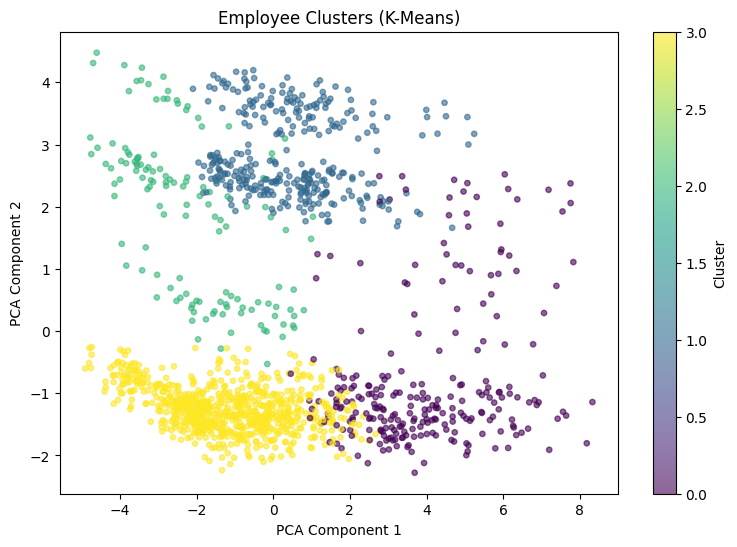

In [ ]:
plt.figure(figsize=(9, 6))
plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=kmeans_labels, cmap="viridis", alpha=0.6, s=15
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Employee Clusters (K-Means)")
plt.colorbar(label="Cluster")
plt.show()

CLUSTERING DEPTH

In [ ]:
# Using K=2 for clustering depth
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels_2 = kmeans.fit_predict(X_scaled)

In [ ]:
df["kmeans_clusters_2"] = kmeans_labels_2
df["kmeans_clusters_2"].value_counts()

,count
kmeans_clusters_2,
1,1111
0,359


In [ ]:
df.groupby("kmeans_clusters_2").agg({
    "MonthlyIncome" : "mean",
    "IncomePerExperienceYear" : "mean",
    "YearsWithCurrManager" : "mean",
    "YearsSinceLastPromotion" : "mean",
    "Age" : "mean",
    "JobLevel" : "mean",
    "NumCompaniesWorked" : "mean",
    "MonthlyIncome_per_JobLevel" : "mean",
    "OverTime_Yes" : "mean"
}).round(2)

,MonthlyIncome,IncomePerExperienceYear,YearsWithCurrManager,YearsSinceLastPromotion,Age,JobLevel,NumCompaniesWorked,MonthlyIncome_per_JobLevel,OverTime_Yes
kmeans_clusters_2,,,,,,,,,
0,12958.78,612.98,7.02,4.82,44.43,3.51,3.16,3626.34,0.29
1,4416.84,579.37,3.19,1.34,34.50,1.60,2.54,2762.94,0.28


  Cluster 1 represents the Developing Workforce Employees. The employees in this cluster are in their growth phase. They comprise of people with lesser age, lower monthly income, lesser years with their current manager, lesser income per experience year and Overtime. Employees here are mostly in their early stages building their carrers and starting from lower ranks.

  Cluster 0 represents Established Senior Professionals. Employees here have a stron relationsip wit teir current manager, they are older, they work more overtime, having higher monthly income compared to cluster 0 and have higher Job Level. They have stayed in the company longer.

In [ ]:
kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
kmeans_labels_3 = kmeans.fit_predict(X_scaled)

In [ ]:
df["kmeans_clusters_3"] = kmeans_labels_3
df["kmeans_clusters_3"].value_counts()

,count
kmeans_clusters_3,
2,320
0,269
5,229
1,196
4,190
3,183
6,83


In [ ]:
df.groupby("kmeans_clusters_3").agg({
    "MonthlyIncome" : "mean",
    "IncomePerExperienceYear" : "mean",
    "YearsWithCurrManager" : "mean",
    "YearsSinceLastPromotion" : "mean",
    "Age" : "mean",
    "JobLevel" : "mean",
    "NumCompaniesWorked" : "mean",
    "MonthlyIncome_per_JobLevel" : "mean",
    "OverTime_Yes" : "mean"
}).round(2)

,MonthlyIncome,IncomePerExperienceYear,YearsWithCurrManager,YearsSinceLastPromotion,Age,JobLevel,NumCompaniesWorked,MonthlyIncome_per_JobLevel,OverTime_Yes
kmeans_clusters_3,,,,,,,,,
0,3168.49,523.13,2.60,1.16,33.52,1.15,2.45,2783.06,0.35
1,6762.46,459.67,8.03,4.63,38.67,2.33,2.01,2858.92,0.24
2,6844.25,641.79,4.59,2.38,36.63,2.31,2.69,2948.91,0.29
3,6120.33,575.64,2.41,0.84,38.55,2.08,3.64,2890.14,0.28
4,16539.02,732.22,6.18,4.14,45.85,4.15,3.42,4006.88,0.28
5,3104.77,542.84,2.47,0.91,33.51,1.17,2.60,2726.68,0.24
6,2626.00,708.07,1.66,1.06,30.36,1.08,1.63,2460.66,0.29


Cluster 0: Young Entry-Level (Low Overtime)
Lowest average age (approx. 33.5) and lowest Job Level (1.15). They have the lowest Monthly Income (~$3,168) but a solid Income Per Experience Year, indicating strong entry starting rates. Relatively low overtime (35%).

Cluster 5: Young Entry-Level (High Overtime / Low Turnover Risk)
Similar profile to Cluster 0 (Age ~33.5, Job Level 1.17, Income ~$3,104), but they work significantly fewer hours of overtime (24%) and have stable, recent management relationships.

Cluster 6: Youngest "Gig-Hoppers" (Highest Attrition Risk)
The youngest group (average age 30) with the lowest Job Level (1.08) and lowest Monthly Income ($2,626). They have high overtime (29%) and very low tenure with their current manager (1.66 years), marking them as a high-risk group for early turnover.

Cluster 2: Fast-Track Mid-Levels
Mid-thirties (Age ~36.6) with solid mid-management status (Job Level 2.31). They command an efficient income-to-level ratio ($2,948 per level) and exhibit balanced tenure metrics across the board.

Cluster 3: Mid-Level Veterans (Stagnant / Low Growth)
Slightly older mid-levels (Age ~38.5) but stuck at a lower Job Level (2.08) and lower Income Per Experience Year ($575). They have very low tenure with their current manager (2.41 years), indicating potential career stagnation.

Cluster 1: Promoted Senior Leaders (High Promotion Stagnation)
Late-thirties professionals (Age 38.6) with high Job Levels (2.33) and strong Monthly Income ($6,762). However, they have the highest time elapsed since their last promotion (4.63 years), making them prime candidates for a retention/progression review.

Cluster 4: Elite Executive Tier
The oldest (Age 45.8), highest-earning cluster by a massive margin ($16,539 monthly). They hold the highest Job Level(4.15) and Income Per Experience year(732.22). They have long managerial stability (6.18 years) and normal promotion cycles.

PART 4 - CLASSIFICATION

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42, stratify=Y)

In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, Y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_proba_lr = lr.predict_proba(X_test)[:, 1]

In [ ]:
y_pred_train = lr.predict(X_train)
y_pred_train[:5]

array([0., 0., 0., 0., 0.])

In [ ]:
results_df = pd.DataFrame({
    "Actual" : Y_train,
    "Predicted" : y_pred_train
})
display(results_df.head(10))

,Actual,Predicted
1194,0.0,0.0
128,0.0,0.0
810,0.0,0.0
478,0.0,0.0
491,0.0,0.0
323,1.0,0.0
258,0.0,0.0
812,0.0,0.0
1132,0.0,0.0
996,0.0,0.0


In [ ]:
y_pred_test = lr.predict(X_test)
y_pred_test[:5]

array([0., 0., 0., 0., 0.])

In [ ]:
results_df_test = pd.DataFrame({
    "Actual" : Y_test,
    "Predicted" : y_pred_test
})
display(results_df_test.head(10))

,Actual,Predicted
1061,0.0,0.0
891,0.0,0.0
456,0.0,0.0
922,0.0,0.0
69,1.0,0.0
1164,0.0,0.0
406,0.0,0.0
1330,0.0,0.0
1232,0.0,0.0
1311,0.0,0.0


In [ ]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "Importance" : lr.coef_[0]
}).sort_values(ascending=False, by="Importance")
display(feature_importance.head(10))

,Feature,Importance
47,OverTime_Yes,0.866801
9,MonthlyIncome,0.805050
27,BusinessTravel_Travel_Frequently,0.783035
38,JobRole_Laboratory Technician,0.667931
11,NumCompaniesWorked,0.535275
43,JobRole_Sales Executive,0.519575
21,YearsSinceLastPromotion,0.487882
28,BusinessTravel_Travel_Rarely,0.479295
44,JobRole_Sales Representative,0.478070
2,DistanceFromHome,0.411237


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
print(classification_report(Y_train, y_pred_train))

              precision    recall  f1-score   support

         0.0       0.91      0.98      0.94       986
         1.0       0.82      0.52      0.63       190

    accuracy                           0.90      1176
   macro avg       0.87      0.75      0.79      1176
weighted avg       0.90      0.90      0.89      1176



In [ ]:
print(classification_report(Y_test, y_pred_test))

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92       247
         1.0       0.65      0.36      0.47        47

    accuracy                           0.87       294
   macro avg       0.77      0.66      0.70       294
weighted avg       0.85      0.87      0.85       294



In [ ]:
print(f"Confusion Matrix(Test Set): ")
cm = confusion_matrix(Y_test, y_pred_test)
print(cm)

Confusion Matrix(Test Set): 
[[238   9]
 [ 30  17]]


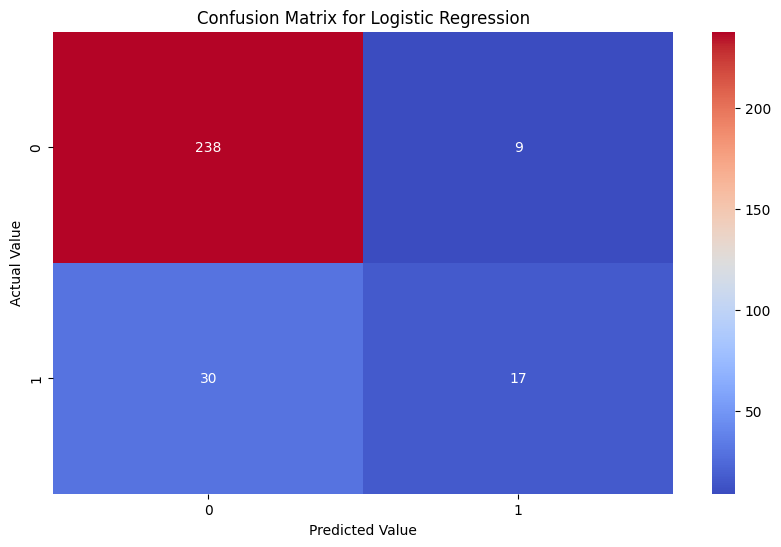

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.title("Confusion Matrix for Logistic Regression")
plt.show()

DECISION TREE CLASSIFIER

In [ ]:
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred_dt = dt.predict(X_train)
y_pred_train[:5]

array([0., 0., 0., 0., 0.])

In [ ]:
y_pred_dt2 = dt.predict(X_test)
y_pred_test[:5]

array([0., 0., 0., 0., 0.])

In [ ]:
y_proba_dt = dt.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(Y_train, y_pred_dt))

              precision    recall  f1-score   support

         0.0       0.89      0.98      0.93       986
         1.0       0.78      0.36      0.49       190

    accuracy                           0.88      1176
   macro avg       0.83      0.67      0.71      1176
weighted avg       0.87      0.88      0.86      1176



In [ ]:
print(classification_report(Y_test, y_pred_dt2))

              precision    recall  f1-score   support

         0.0       0.87      0.96      0.91       247
         1.0       0.53      0.21      0.30        47

    accuracy                           0.84       294
   macro avg       0.70      0.59      0.61       294
weighted avg       0.81      0.84      0.81       294



In [ ]:
feature_importance = pd.DataFrame({
    "Feature" : X.columns,
    "importance" : dt.feature_importances_
}).sort_values("importance", ascending=False)
display(feature_importance.head())

,Feature,importance
16,TotalWorkingYears,0.270626
9,MonthlyIncome,0.126137
1,DailyRate,0.118342
47,OverTime_Yes,0.109409
0,Age,0.102894


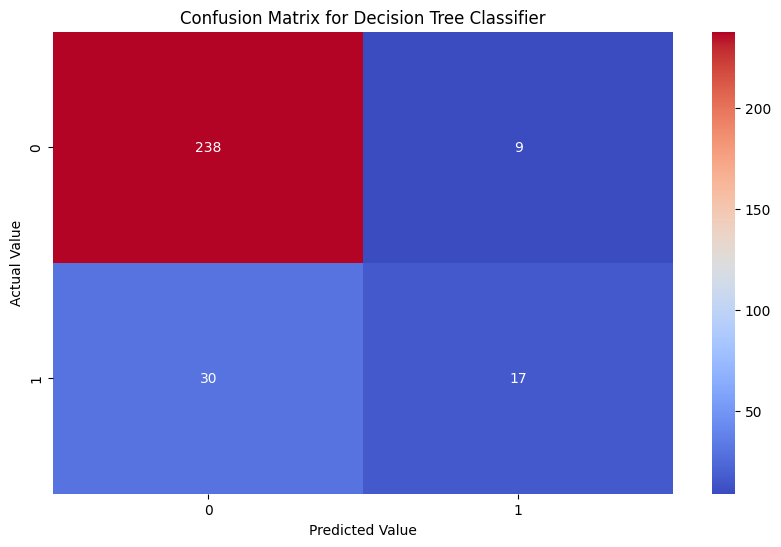

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.title("Confusion Matrix for Decision Tree Classifier")
plt.show()

RANDOM FOREST CLASSIFIER

In [ ]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_train)
y_pred_rf[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
y_pred_rf2 = rf.predict(X_test)
y_pred_rf2[:10]

array([1., 0., 0., 0., 0., 0., 0., 0., 0., 1.])

In [ ]:
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [ ]:
rf_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).head(10)

rf_importance

,feature,importance
9,MonthlyIncome,0.076442
16,TotalWorkingYears,0.069537
47,OverTime_Yes,0.065580
0,Age,0.061677
25,WorkingExperience,0.060577
19,YearsAtCompany,0.051232
22,YearsWithCurrManager,0.045703
24,TenureRatio,0.036829
23,IncomePerExperienceYear,0.036253
15,StockOptionLevel,0.035018


In [ ]:
print(classification_report(Y_train, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93       986
         1.0       0.93      0.22      0.35       190

    accuracy                           0.87      1176
   macro avg       0.90      0.61      0.64      1176
weighted avg       0.88      0.87      0.83      1176



In [ ]:
print(classification_report(Y_test, y_pred_rf2))

              precision    recall  f1-score   support

         0.0       0.85      0.97      0.90       247
         1.0       0.30      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.57      0.52      0.50       294
weighted avg       0.76      0.83      0.78       294



In [ ]:
print("Confusion Matrix(Test Set): ")
cm3=confusion_matrix(Y_test, y_pred_rf2)
print(cm3)

Confusion Matrix(Test Set): 
[[240   7]
 [ 44   3]]


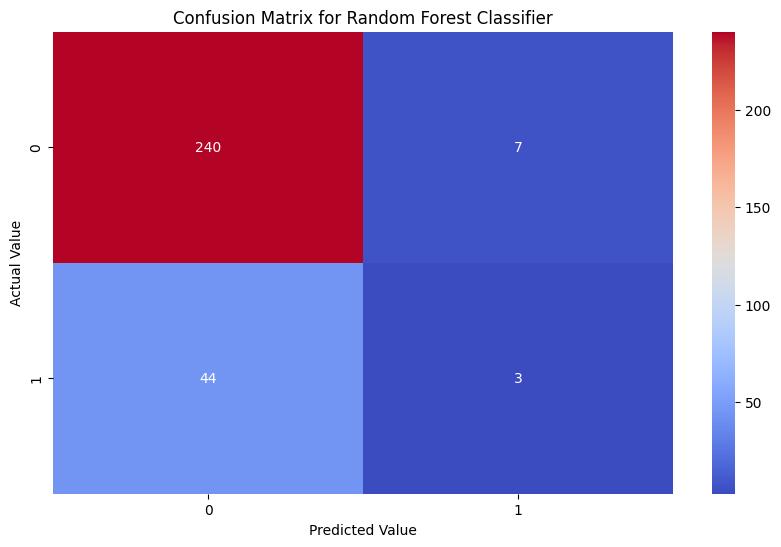

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(cm3, annot=True, fmt="d", cmap="coolwarm")
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.title("Confusion Matrix for Random Forest Classifier")
plt.show()

In [ ]:
def evaluate_model(name, y_true, y_pred, y_prob):
  return{
      "model" : name,
      "accuracy" : accuracy_score(y_true, y_pred),
      "precision" : precision_score(y_true, y_pred),
      "recall" : recall_score(y_true, y_pred),
      "f1_score" : f1_score(y_true, y_pred),
      "roc_auc" : roc_auc_score(y_true, y_prob)
  }

In [ ]:
results = pd.DataFrame([
    evaluate_model("Logistic Regression", Y_test, y_pred_test, y_proba_lr),
    evaluate_model("Decision Tree", Y_test, y_pred_dt2, y_proba_dt),
    evaluate_model("Random Forest", Y_test, y_pred_rf2, y_proba_rf)
])
results.round(5)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression,0.86735,0.65385,0.36170,0.46575,0.81747
1,Decision Tree,0.84354,0.52632,0.21277,0.30303,0.71307
2,Random Forest,0.82653,0.30000,0.06383,0.10526,0.74821


For the classification techniques, I used:

1. Logistic Regression because it is simple, fast, and interpretable, making it useful for understanding how factors like overtime, income, or job satisfaction affect the likelihood of employees leaving. It is interpretable linear baseline; shows which features push the probability up or down.

2. Decision Tree because it can capture nonlinear relationships and decision rules in employee behavior. It is easy to visualize and explain, showing clear paths such as employees with low job satisfaction and high overtime are more likely to leave.

3. Random Forest because improves prediction accuracy by combining multiple decision trees. It reduces overfitting and handles complex patterns in HR data better, making it more reliable for predicting employee attrition compared to a single Decision Tree.

IMBALANCE HANDLING - (LOGISTIC REGRESSION)

In [ ]:
# Class weight
lr_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
lr_weighted.fit(X_train, Y_train)
y_pred_w = lr_weighted.predict(X_test)
y_prob_w = lr_weighted.predict_proba(X_test)[:, 1]

print("Logistic Regression + Class Weights:")
print(classification_report(Y_test, y_pred_w))

Logistic Regression + Class Weights:
              precision    recall  f1-score   support

         0.0       0.92      0.79      0.85       247
         1.0       0.37      0.64      0.47        47

    accuracy                           0.77       294
   macro avg       0.64      0.71      0.66       294
weighted avg       0.83      0.77      0.79       294



In [ ]:
#Threshold Tuning
thresholds=[0.5,0.4,0.3,0.2]
threshold_results=[]

for t in thresholds:
  y_pred_t = (y_proba_lr >= t).astype(int)
  threshold_results.append({
    "threshold": t,
    "precision": precision_score(Y_test, y_pred_t),
    "recall": recall_score(Y_test, y_pred_t),
    "f1": f1_score(Y_test, y_pred_t),
    })
pd.DataFrame(threshold_results).round(3)

,threshold,precision,recall,f1
0,0.5,0.654,0.362,0.466
1,0.4,0.583,0.447,0.506
2,0.3,0.532,0.532,0.532
3,0.2,0.433,0.617,0.509


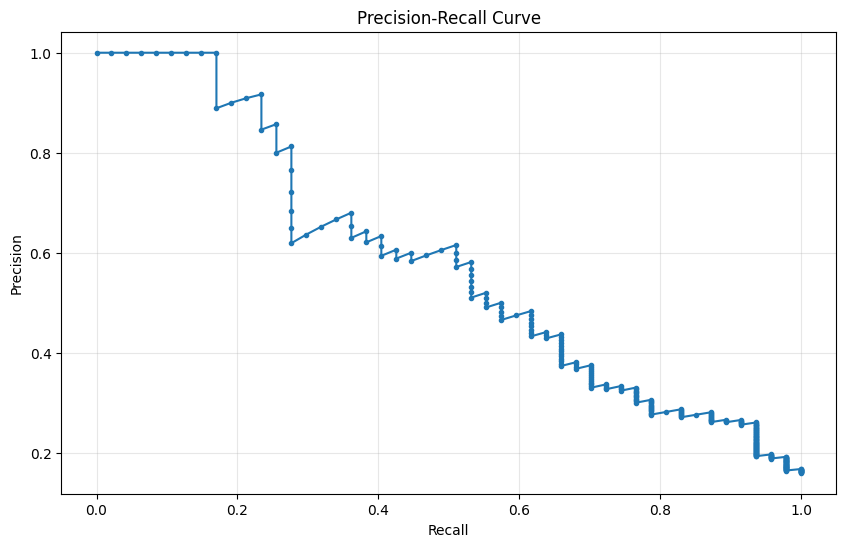

In [ ]:
from sklearn.metrics import precision_recall_curve
pre, rec, thr = precision_recall_curve(Y_test, y_proba_lr)
plt.figure(figsize=(10,6))
plt.plot(rec, pre, marker="o", markersize=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [ ]:
Y_train_smote.value_counts()

,count
Attrition_Yes,
0.0,986
1.0,986


In [ ]:
lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_smote, Y_train_smote)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr_smote = lr_smote.predict(X_test)
y_proba_lr_smote = lr_smote.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(Y_test, y_pred_lr_smote))

              precision    recall  f1-score   support

         0.0       0.92      0.81      0.86       247
         1.0       0.38      0.64      0.48        47

    accuracy                           0.78       294
   macro avg       0.65      0.72      0.67       294
weighted avg       0.84      0.78      0.80       294



In [ ]:
y_pred_threshold = (y_proba_lr >= 0.3).astype(int)

imbalance_results = pd.DataFrame([
    evaluate_model("Baseline LR", Y_test, y_pred_test, y_proba_lr),
    evaluate_model("LR + threshold 0.3", Y_test, y_pred_threshold, y_proba_lr),
    evaluate_model("LR + SMOTE", Y_test, y_pred_lr_smote, y_proba_lr_smote),
])

imbalance_results.round(3)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline LR,0.867,0.654,0.362,0.466,0.817
1,LR + threshold 0.3,0.850,0.532,0.532,0.532,0.817
2,LR + SMOTE,0.779,0.385,0.638,0.480,0.797


IMBALANCE HANDLING - (RANDOM FOREST)

In [ ]:
# Class weight
rf_weighted = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=20, min_samples_leaf=10, random_state=42, n_jobs=-1, class_weight="balanced")
rf_weighted.fit(X_train, Y_train)
y_pred_w_rf = rf_weighted.predict(X_test)
y_prob_w_rf = rf_weighted.predict_proba(X_test)[:, 1]

print("Random Forest + Class Weights:")
print(classification_report(Y_test, y_pred_w_rf))

Random Forest + Class Weights:
              precision    recall  f1-score   support

         0.0       0.90      0.89      0.89       247
         1.0       0.45      0.49      0.47        47

    accuracy                           0.82       294
   macro avg       0.68      0.69      0.68       294
weighted avg       0.83      0.82      0.83       294



In [ ]:
# Threshold tuning
thresholds=[0.5,0.4,0.3,0.2]
threshold_results=[]

for t in thresholds:
  y_pred_t = (y_proba_rf >= t).astype(int)
  threshold_results.append({
    "threshold": t,
    "precision": precision_score(Y_test, y_pred_t),
    "recall": recall_score(Y_test, y_pred_t),
    "f1": f1_score(Y_test, y_pred_t),
    })
pd.DataFrame(threshold_results).round(3)

,threshold,precision,recall,f1
0,0.5,0.300,0.064,0.105
1,0.4,0.316,0.128,0.182
2,0.3,0.355,0.234,0.282
3,0.2,0.373,0.596,0.459


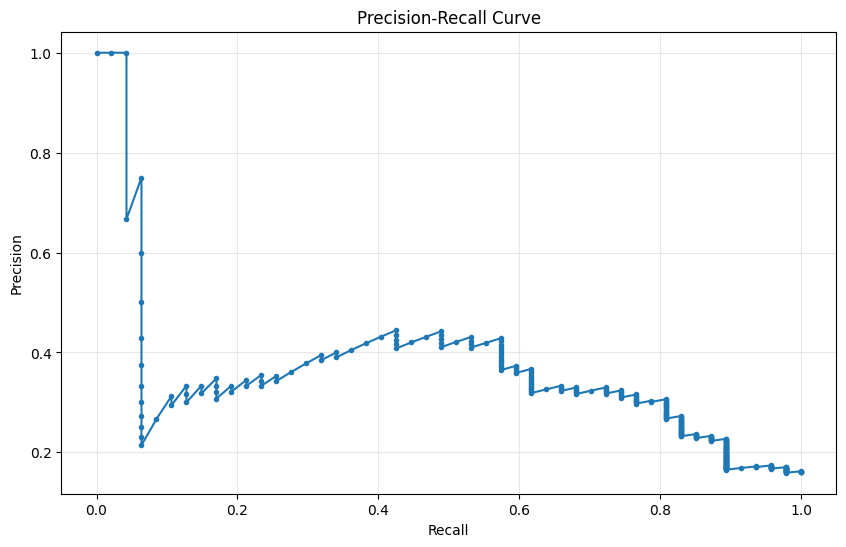

In [ ]:
from sklearn.metrics import precision_recall_curve
pre, rec, thr = precision_recall_curve(Y_test, y_proba_rf)
plt.figure(figsize=(10,6))
plt.plot(rec, pre, marker="o", markersize=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# SMOTE (RANDOM FOREST)
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [ ]:
Y_train_smote.value_counts()

,count
Attrition_Yes,
0.0,986
1.0,986


In [ ]:
rf_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf_smote.fit(X_train_smote, Y_train_smote)

RandomForestClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       n_jobs=-1, random_state=42)

In [ ]:
y_pred_rf_smote = rf_smote.predict(X_test)
y_proba_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(Y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89       247
         1.0       0.42      0.34      0.38        47

    accuracy                           0.82       294
   macro avg       0.65      0.63      0.64       294
weighted avg       0.81      0.82      0.81       294



In [ ]:
y_pred_threshold = (y_proba_rf >= 0.2).astype(int)

imbalance_results = pd.DataFrame([
    evaluate_model("Baseline RF", Y_test, y_pred_rf2, y_proba_rf),
    evaluate_model("RF + threshold 0.2", Y_test, y_pred_threshold, y_proba_rf),
    evaluate_model("RF + SMOTE", Y_test, y_pred_rf_smote, y_proba_rf_smote),
])

imbalance_results.round(3)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline RF,0.827,0.300,0.064,0.105,0.748
1,RF + threshold 0.2,0.776,0.373,0.596,0.459,0.748
2,RF + SMOTE,0.820,0.421,0.340,0.376,0.786


IMBALANCE HANDLING - (DECISION TREE)

In [ ]:
# Class weight
dt_weighted = RandomForestClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42, class_weight="balanced")
dt_weighted.fit(X_train, Y_train)
y_pred_w_dt = dt_weighted.predict(X_test)
y_prob_w_dt = dt_weighted.predict_proba(X_test)[:, 1]

print("Decision Tree + Class Weights:")
print(classification_report(Y_test, y_pred_w_dt))

Decision Tree + Class Weights:
              precision    recall  f1-score   support

         0.0       0.91      0.88      0.89       247
         1.0       0.46      0.55      0.50        47

    accuracy                           0.83       294
   macro avg       0.69      0.72      0.70       294
weighted avg       0.84      0.83      0.83       294



In [ ]:
# Threshold Tuning
thresholds=[0.5,0.4,0.3,0.2]
threshold_results=[]

for t in thresholds:
  y_pred_t = (y_proba_dt >= t).astype(int)
  threshold_results.append({
    "threshold": t,
    "precision": precision_score(Y_test, y_pred_t),
    "recall": recall_score(Y_test, y_pred_t),
    "f1": f1_score(Y_test, y_pred_t),
    })
pd.DataFrame(threshold_results).round(3)

,threshold,precision,recall,f1
0,0.5,0.526,0.213,0.303
1,0.4,0.455,0.213,0.290
2,0.3,0.360,0.383,0.371
3,0.2,0.337,0.638,0.441


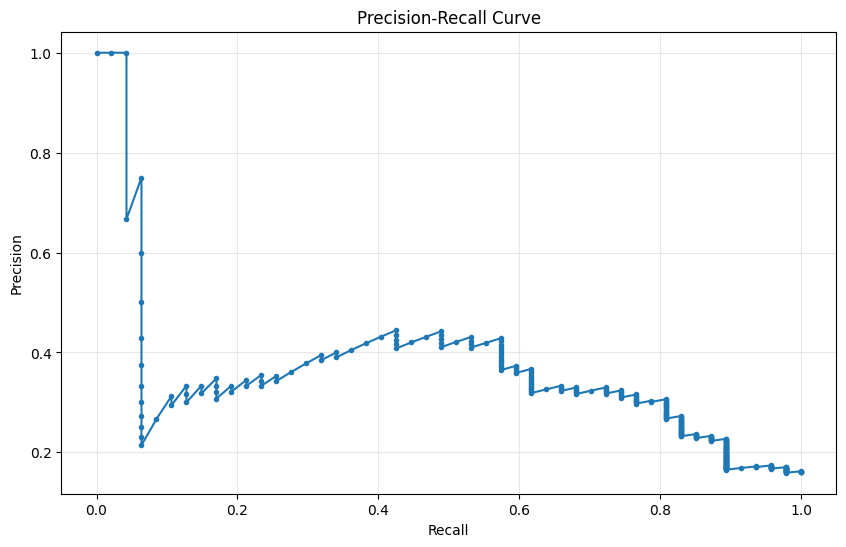

In [ ]:
from sklearn.metrics import precision_recall_curve
pre, rec, thr = precision_recall_curve(Y_test, y_proba_rf)
plt.figure(figsize=(10,6))
plt.plot(rec, pre, marker="o", markersize=3)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, Y_train_smote = smote.fit_resample(X_train, Y_train)

In [ ]:
dt_smote = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_smote.fit(X_train_smote,Y_train_smote)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
dt_smote = DecisionTreeClassifier(max_depth=5, min_samples_split=20, min_samples_leaf=10, random_state=42)
dt_smote.fit(X_train_smote,Y_train_smote)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [ ]:
y_pred_dt_smote = dt_smote.predict(X_test)
y_proba_dt_smote = dt_smote.predict_proba(X_test)[:, 1]

In [ ]:
print(classification_report(Y_test, y_pred_rf_smote))

              precision    recall  f1-score   support

         0.0       0.88      0.91      0.89       247
         1.0       0.42      0.34      0.38        47

    accuracy                           0.82       294
   macro avg       0.65      0.63      0.64       294
weighted avg       0.81      0.82      0.81       294



In [ ]:
y_pred_threshold = (y_proba_rf >= 0.2).astype(int)

imbalance_results = pd.DataFrame([
    evaluate_model("Baseline DT", Y_test, y_pred_dt2, y_proba_dt),
    evaluate_model("DT + threshold 0.2", Y_test, y_pred_threshold, y_proba_dt),
    evaluate_model("DT + SMOTE", Y_test, y_pred_dt_smote, y_proba_dt_smote),
])

imbalance_results.round(3)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Baseline DT,0.844,0.526,0.213,0.303,0.713
1,DT + threshold 0.2,0.776,0.373,0.596,0.459,0.713
2,DT + SMOTE,0.799,0.342,0.277,0.306,0.677


PART 6 - THE TIE IN

In [ ]:
attrition_rate = df.groupby('kmeans_clusters')['Attrition_Yes'].agg(
    Total='count',
    Positive_Class='sum',
    Attrition_Rate='mean'
).reset_index()

attrition_rate['Attrition_Rate_%'] = (attrition_rate['Attrition_Rate'] * 100).round(2)

print(attrition_rate[['kmeans_clusters', 'Total', 'Positive_Class', 'Attrition_Rate_%']])

   kmeans_clusters  Total  Positive_Class  Attrition_Rate_%
0                0    256              15              5.86
1                1    319              55             17.24
2                2    133              44             33.08
3                3    762             123             16.14


Cluster 2 and Cluster 0 were the strongest predictors of my dataset.

Cluster 2 which represents Low Income Early Creer drifters has the highest rate of attrition of 33.08% amongst the clusters. It is the strongest positive predictor of the dataset.

Cluster 0 which represents Tenured High Level Professionals. This is the stongest negative predictor with an attrition rate of 5.86%.

It also implies that the clustering technique applied without any knowledge of the target variable produced clusters with such divergent attrition rates confirms that the features used capture genuine and meaningful patterns in employee turnover behaviour.

PART 7 - CONCLUSION AND RECOMMENDATION

we would deploy Logistic Regression because it had a performance than Decision Tree and Random Forest both in their baseline model and after imbalance handling. we would deploy Logistic Regression with threshold = 0.3 because it gave the best evaluation metric required for our IBM HR Employee Attrition.

We focus more on recall and ROC-AUC because we want to catch the actual leavers before they do and Logistic Regression with threshold of 0.3 provided the best recall value which is 0.532 and ROC-AUC OF 0.532

If I had another month, I would try other algorithms like BOOSTING techniques.

2. I would do deep feature engineering

3. I would also do hyperparameter tuning

The hardest decision we made was choosing our value of our final K. Our elbow method gave us 4 while the silhouette score suggested 2. We did not pick 2 as the final K because it had broad personas and gave limited insights for the attrition while K=4 revealed actionable insights as to the cause of leaving and staying.

This decision taught the team that in applied data science, the right answer is not always the one with the highest score — it is the one that best serves the problem you are trying to solve.